In [1]:
# Usual imports
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from rich.progress import Progress
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# RobustBench
import robustbench
from robustbench.utils import load_model
from secml.utils import fm
from secml import settings

from nonconformist.cp import IcpRegressor
from nonconformist.nc import RegressorNc, QuantileRegErrFunc

import adv_lib

2026-07-16 10:52:04.899236: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-16 10:52:04.999657: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-16 10:52:07.015579: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## CUDA

In [2]:
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CUDA available: True
GPU name: NVIDIA GeForce RTX 4090


## Utilities

In [3]:
class ProbRegressionWrapper(nn.Module):
    def __init__(self, classifier):
        super().__init__()
        self.classifier = classifier  # pretrained classifier

    def forward(self, x):
        logits = self.classifier(x)
        probs = F.softmax(logits, dim=1)
        return probs
    
def load_cifar10_splits(
    n_train=1000,
    n_cal=500,
    n_test=2000
):
    transform = T.ToTensor()

    # Load datasets
    trainset = torchvision.datasets.CIFAR10(
        root='/home/acarlevaro/Sources/albi/data', train=True, download=True, transform=transform
    )

    # Random selection (only indices)
    perm_train = torch.randperm(len(trainset))

    idx_train = perm_train[:n_train]
    idx_cal = perm_train[n_train:n_train+n_cal]
    idx_test = perm_train[:n_test]

    # Extract only needed samples (NO full dataset stacking)
    X_train = torch.stack([trainset[i][0] for i in idx_train])
    y_train = torch.tensor([trainset[i][1] for i in idx_train])

    X_cal = torch.stack([trainset[i][0] for i in idx_cal])
    y_cal = torch.tensor([trainset[i][1] for i in idx_cal])

    X_test = torch.stack([trainset[i][0] for i in idx_test])
    y_test = torch.tensor([trainset[i][1] for i in idx_test])

    return (X_train, y_train), (X_cal, y_cal), (X_test, y_test)

## Dataset

### CIFAR_10

In [4]:
(train_X, train_y), (cal_X, cal_y), (test_X, test_y) = load_cifar10_splits(
    n_train=100, n_cal=100, n_test=100
)

train_X = train_X.to(device)
train_y = train_y.to(device)

cal_X = cal_X.to(device)
cal_y = cal_y.to(device)

test_X = test_X.to(device)
test_y = test_y.to(device)

### One-hot encode 
#### (from classification to regression)

In [5]:
num_classes = 10
train_y_oh = F.one_hot(train_y, num_classes=num_classes).float()
cal_y_oh = F.one_hot(cal_y, num_classes=num_classes).float()
test_y_oh = F.one_hot(test_y, num_classes=num_classes).float()

## RobustBench

### Regression on Correct-Class Probability

We treat the pretrained classification model as a regressor on the **true-class probability**.  
The regression target is the logit of the true class probability:


$$ y_{\text{reg}} = \text{logit}\big(p_{\text{true class}}(x)\big) = \log \frac{p_{\text{true class}}(x)}{1 - p_{\text{true class}}(x)} $$ 


The regressor $ g_\phi(x) $ predicts this real value:

$$
\hat{y}_{\text{reg}} = g_\phi(x) \approx y_{\text{reg}}
$$

Performance can be evaluated using MSE on the predicted correct-class probability, classification accuracy, and calibration metrics.


In [6]:
#L2#
#Wang2023Better_WRN-70-16

#Linf#
#Andriushchenko2020Understanding

In [6]:
output_dir = fm.join(settings.SECML_MODELS_DIR, 'robustbench')

### Load a model

In [7]:
def load_rb_model(model_name, device, norm = 'L2', model_dir="./models"):
    model = load_model(model_name, norm=norm, model_dir=model_dir).to(device)
    return model

In [8]:
# L2
model_names = [
    "Wang2023Better_WRN-70-16",
    #"Rebuffi2021Fixing_70_16_cutmix_extra",  
    #"Amini2024MeanSparse_S-WRN-70-16",  
    #"Augustin2020Adversarial",  
    #"Wu2020Adversarial" 
    #"Ding2020MMA"
]

In [9]:
models = {}

for name in model_names:
    print(f"Loading {name}...")
    mdl = load_rb_model(name, 'cuda','L2', model_dir=output_dir)
    models[name] = ProbRegressionWrapper(mdl)

print("\nLoaded models:")
print(list(models.keys()))


Loading Wang2023Better_WRN-70-16...

Loaded models:
['Wang2023Better_WRN-70-16']


In [10]:
reg_wu = models["Wang2023Better_WRN-70-16"]

In [11]:
def get_correct_probs(model, X, y):
    with torch.no_grad():
        probs = model(X)                # shape: (n, 10)
        correct_probs = probs[range(len(y)), y]  # shape: (n,)
    return correct_probs.to(device)

### Evaluate the model

In [13]:
def evaluate_model_probs(model, X, y, device, batch_size=128):
    """
    Compute probabilities, correct-class probs, MSE, accuracy for a model.
    """
    model.eval()
    all_probs = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = X[i:i + batch_size].to(device)
            p = model(batch)  # (batch, 10)
            all_probs.append(p)

    probs = torch.cat(all_probs, dim=0)          # (n_samples, 10)
    correct_probs = probs[range(len(y)), y]      # (n_samples,)

    mse = ((correct_probs - 1) ** 2).mean().item()

    preds = probs.argmax(dim=1)
    acc = (preds == y).float().mean().item()

    return probs, correct_probs, mse, acc


========== Evaluating model: Wu2020Adversarial ==========
MSE: 0.052295
Accuracy: 98.20%


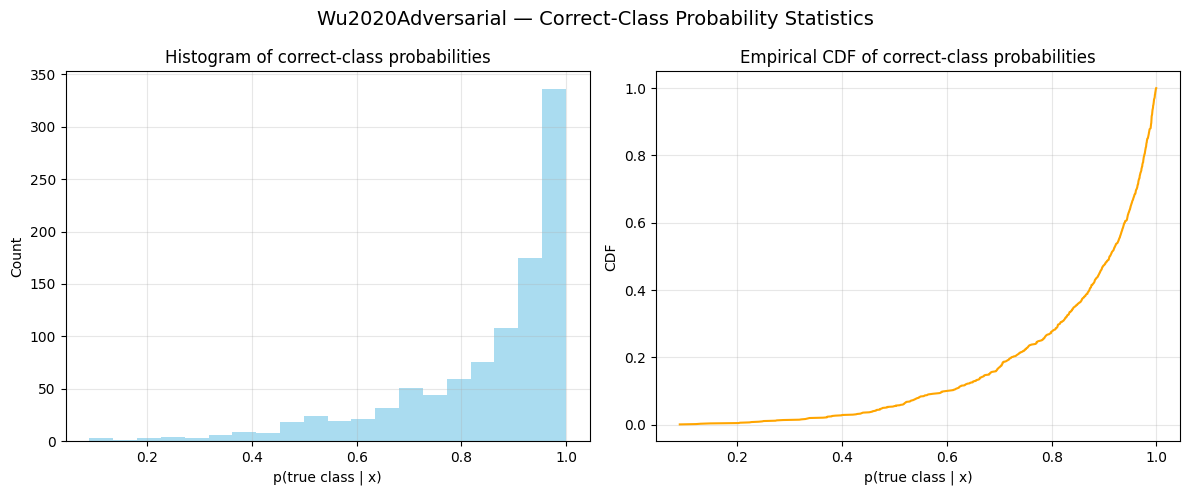

In [17]:
for name, model in models.items():
    print(f"\n========== Evaluating model: {name} ==========")
    probs, correct_probs, mse, acc = evaluate_model_probs(model, test_X, test_y, device)

    print(f"MSE: {mse:.6f}")
    print(f"Accuracy: {acc*100:.2f}%")

    # ----------------------------
    # Plots: Histogram + CDF
    # ----------------------------
    plt.figure(figsize=(12, 5))
    plt.suptitle(f"{name} — Correct-Class Probability Statistics", fontsize=14)

    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(correct_probs.cpu().numpy(), bins=20, alpha=0.7, color='skyblue')
    plt.title("Histogram of correct-class probabilities")
    plt.xlabel("p(true class | x)")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    # CDF
    plt.subplot(1, 2, 2)
    sorted_probs, _ = torch.sort(correct_probs.cpu())
    cdf = torch.arange(1, len(sorted_probs) + 1) / len(sorted_probs)

    plt.plot(sorted_probs.numpy(), cdf.numpy(), color='orange')
    plt.title("Empirical CDF of correct-class probabilities")
    plt.xlabel("p(true class | x)")
    plt.ylabel("CDF")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Attack

In [12]:
import torch
import torch.nn as nn


class ProbToLogitsWrapper(nn.Module):
    """
    Converts probability outputs into logits for adversarial attacks.
    """
    def __init__(self, model_prob):
        super().__init__()
        self.model_prob = model_prob

    def forward(self, x):
        probs = self.model_prob(x)
        logits = torch.log(probs + 1e-12)
        return logits

In [13]:
from autoattack import AutoAttack


def attack_autoattack(
    model,
    X,
    y,
    eps,
    norm,
    attack_type="AA",
    bs=128,
    device="cuda"
):

    model_attack = ProbToLogitsWrapper(model).to(device)
    model_attack.eval()

    if attack_type == "AA":
        attacks = [
            'apgd-ce',
            'apgd-dlr',
            'fab',
        ]

    elif attack_type == "APGD":
        attacks = [
            'apgd-ce'
        ]

    elif attack_type == "FAB":
        attacks = [
            'fab'
        ]

    else:
        raise ValueError(
            f"Unknown AutoAttack mode {attack_type}"
        )


    adversary = AutoAttack(
        model_attack,
        norm=norm,
        eps=eps,
        version='custom',
        attacks_to_run=attacks,
        device=device,
        verbose=True
    )


    # opzionale per velocità
    adversary.apgd.n_iter = 100


    X_adv = adversary.run_standard_evaluation(
        X.to(device),
        y.to(device),
        bs=bs
    )


    return X_adv

In [14]:
import torchattacks
import foolbox as fb

def attack_pgd100(
    model,
    X,
    y,
    eps,
    norm,
    bs=128,
    device="cuda"
):

    model_attack = ProbToLogitsWrapper(model).to(device)
    model_attack.eval()


    # Foolbox model
    fmodel = fb.PyTorchModel(
        model_attack,
        bounds=(0,1),
        device=device
    )


    if norm == "L2":

        attack = fb.attacks.L2ProjectedGradientDescentAttack(
            steps=100,
            rel_stepsize=0.033,
            random_start=True
        )

    elif norm == "Linf":

        attack = fb.attacks.LinfProjectedGradientDescentAttack(
            steps=100,
            rel_stepsize=0.01,
            random_start=True
        )

    else:
        raise ValueError("Norm not supported")


    X_adv = []

    for i in range(0, len(X), bs):

        x_batch = X[i:i+bs].to(device)
        y_batch = y[i:i+bs].to(device)


        _, adv_batch, _ = attack(
            fmodel,
            x_batch,
            y_batch,
            epsilons=eps
        )

        X_adv.append(adv_batch.detach())


    X_adv = torch.cat(X_adv, dim=0)

    return X_adv

In [15]:
def attack_cw(
    model,
    X,
    y,
    eps,
    norm,
    bs=128,
    device="cuda"
):

    model_attack = ProbToLogitsWrapper(model).to(device)


    attack = torchattacks.CW(
        model_attack,
        c=1,
        kappa=0,
        steps=100,
        lr=0.01
    )


    X_adv = attack(
        X.to(device),
        y.to(device)
    )

    return X_adv

In [16]:
def attack_ddn(
    model,
    X,
    y,
    eps,
    norm="L2",
    bs=128,
    device="cuda"
):

    fmodel = fb.PyTorchModel(
        ProbToLogitsWrapper(model).to(device),
        bounds=(0,1)
    )

    attack = fb.attacks.DDNAttack()

    _, advs, _ = attack(
        fmodel,
        X.to(device),
        y.to(device),
        epsilons=eps
    )

    return advs

In [17]:
def attack_fmn(
    model,
    X,
    y,
    eps,
    norm="L2",
    bs=128,
    device="cuda"
):

    fmodel = fb.PyTorchModel(
        ProbToLogitsWrapper(model).to(device),
        bounds=(0,1)
    )

    attack = fb.attacks.L2FMNAttack()

    _, advs, _ = attack(
        fmodel,
        X.to(device),
        y.to(device),
        epsilons=eps
    )

    return advs

In [23]:
from adv_lib.attacks import alma
from adv_lib.attacks.trust_region import tr
from tqdm.auto import tqdm

def attack_advlib_l2(
    model,
    X,
    y,
    attack_name,
    eps,
    bs=128,
    device="cuda"
):

    model.eval()

    X_adv = []


    for i in tqdm(
        range(0, len(X), bs), 
        desc=f"Running {attack_name}", 
        leave=True
    ):

        x_batch = X[i:i+bs].to(device)
        y_batch = y[i:i+bs].to(device)


        if attack_name == "ALMA":

            adv_batch = alma(
                model,
                x_batch,
                y_batch,
            )


        else:
            raise ValueError(
                f"{attack_name} unknown"
            )


        X_adv.append(
            adv_batch.detach().cpu()
        )


    return torch.cat(X_adv)

In [24]:
def attack_foolbox_l2(
    model,
    X,
    y,
    attack_name,
    eps,
    bs=128,
    device="cuda"
):

    model.eval()


    fmodel = fb.PyTorchModel(
        ProbToLogitsWrapper(model).to(device),
        bounds=(0,1)
    )


    attacks = {

        "CW":
            fb.attacks.L2CarliniWagnerAttack(),

        "DDN":
            fb.attacks.DDNAttack(),

        "FMN":
            fb.attacks.L2FMNAttack(),

        "EAD":
            fb.attacks.EADAttack(),

        "PGD100":
            fb.attacks.L2ProjectedGradientDescentAttack(
                steps=100
            )
    }


    if attack_name not in attacks:
        raise ValueError(
            f"{attack_name} not supported"
        )


    attack = attacks[attack_name]


    X_adv = []


    for i in tqdm(
        range(0, len(X), bs), 
        desc=f"Running {attack_name}", 
        leave=True
    ):

        x_batch = X[i:i+bs].to(device)
        y_batch = y[i:i+bs].to(device)


        _, adv_batch, success = attack(
            fmodel,
            x_batch,
            y_batch,
            epsilons=eps
        )


        X_adv.append(
            adv_batch.cpu()
        )


    return torch.cat(X_adv)

In [25]:
def generate_adversarial_examples(
    model,
    X,
    y,
    attack_name,
    eps,
    norm="L2",
    bs=128,
    device="cuda"
):

    attack_name = attack_name.upper()


    if attack_name in [
        "AA",
        "APGD",
        "FAB"
    ]:

        return attack_autoattack(
            model,
            X,
            y,
            eps,
            norm,
            attack_type=attack_name,
            bs=bs,
            device=device
        )


    elif attack_name in [
    "CW",
    "DDN",
    "FMN",
    "EAD",
    "PGD100"
    ]:

        return attack_foolbox_l2(
            model,
            X,
            y,
            attack_name,
            eps,
            bs,
            device
        )


    elif attack_name in [
        "ALMA",
    ]:

        return attack_advlib_l2(
            model,
            X,
            y,
            attack_name,
            eps,
            bs,
            device
        )


    else:

        raise NotImplementedError(
            f"{attack_name} not implemented yet"
        )

In [26]:
def combine_attacks(
    model,
    y,
    adv_dict,
    device="cuda"
):

    model.eval()


    attacks = list(adv_dict.keys())

    scores = []


    with torch.no_grad():

        for attack in attacks:

            x_adv = adv_dict[attack].to(device)

            probs = model(x_adv)

            true_prob = probs[
                torch.arange(len(y)),
                y.to(device)
            ]

            scores.append(
                true_prob.cpu()
            )


    scores = torch.stack(
        scores,
        dim=1
    )


    # attack peggiore
    worst_attack = torch.argmin(
        scores,
        dim=1
    )


    combined = torch.zeros_like(
        adv_dict[attacks[0]]
    )


    for i in range(len(y)):

        combined[i] = adv_dict[
            attacks[worst_attack[i]]
        ][i]


    return combined

### Run the attack

### L2 ------ $\varepsilon = 0.5$

In [35]:
ATTACKS = [
    "PGD100",
    #"CW",
    #"EAD",
    "DDN",
    "ALMA",
    #"FAB",
    "FMN",
    #"APGD",
    #"AA"
]

In [33]:
eps = 0.5
batch_size = 8

adv_data = {}


for model_name, model in models.items():

    print(
        f"\n========== Model: {model_name} =========="
    )

    adv_data[model_name] = {}


    for attack_name in ATTACKS:

        print(
            f"\n---- Attack: {attack_name} ----"
        )


        cal_X_adv = generate_adversarial_examples(
            model=model,
            X=cal_X,
            y=cal_y,
            attack_name=attack_name,
            eps=eps,
            norm="L2",
            bs=batch_size,
            device=device
        )


        test_X_adv = generate_adversarial_examples(
            model=model,
            X=test_X,
            y=test_y,
            attack_name=attack_name,
            eps=eps,
            norm="L2",
            bs=batch_size,
            device=device
        )


        adv_data[model_name][attack_name] = {
            "norm": "L2",
            "eps": eps,
            "cal_X_adv": cal_X_adv.cpu(),
            "test_X_adv": test_X_adv.cpu()
        }


print("\nDone.")


========== Model: Wang2023Better_WRN-70-16 ==========

---- Attack: PGD100 ----


Running PGD100:   0%|          | 0/13 [00:00<?, ?it/s]

Running PGD100:   0%|          | 0/13 [00:00<?, ?it/s]


---- Attack: DDN ----


Running DDN:   0%|          | 0/13 [00:00<?, ?it/s]

...


---- Attack: FMN ----


Running FMN:   0%|          | 0/13 [00:00<?, ?it/s]

Running FMN:   0%|          | 0/13 [00:00<?, ?it/s]


---- Attack: COMBINED ----


NotImplementedError: COMBINED not implemented yet

In [36]:
cal_adv_dict = {}
test_adv_dict = {}

for attack in ATTACKS:

    cal_adv_dict[attack] = adv_data[model_name][attack]["cal_X_adv"]

    test_adv_dict[attack] = adv_data[model_name][attack]["test_X_adv"]
    
cal_X_adv_combined = combine_attacks(
    model,
    cal_y,
    cal_adv_dict,
    device=device
)

test_X_adv_combined = combine_attacks(
    model,
    test_y,
    test_adv_dict,
    device=device
)

adv_data[model_name]["COMBINED"] = {
    "norm": "L2",
    "eps": eps,
    "cal_X_adv": cal_X_adv_combined.cpu(),
    "test_X_adv": test_X_adv_combined.cpu()
}

In [37]:
adv_data["Wang2023Better_WRN-70-16"].keys()

dict_keys(['PGD100', 'DDN', 'ALMA', 'FMN', 'COMBINED'])

In [38]:
adv_data

{'Wang2023Better_WRN-70-16': {'PGD100': {'norm': 'L2',
   'eps': 0.5,
   'cal_X_adv': tensor([[[[1.0000, 0.9984, 0.9990,  ..., 0.9995, 0.9972, 0.9950],
             [0.9994, 0.9920, 0.9850,  ..., 0.9849, 0.9792, 1.0000],
             [0.9985, 0.9206, 0.8094,  ..., 0.8313, 0.9402, 0.9975],
             ...,
             [0.9856, 0.9365, 0.8619,  ..., 0.8506, 0.9445, 0.9925],
             [0.9959, 0.9784, 0.9856,  ..., 0.9799, 0.9830, 0.9931],
             [0.9902, 0.9962, 0.9980,  ..., 0.9942, 0.9960, 0.9846]],
   
            [[1.0000, 1.0000, 0.9988,  ..., 1.0000, 0.9993, 0.9993],
             [0.9904, 0.9844, 0.9966,  ..., 0.9956, 0.9913, 0.9997],
             [0.9896, 0.9221, 0.8645,  ..., 0.8714, 0.9501, 0.9946],
             ...,
             [0.9917, 0.9592, 0.8950,  ..., 0.8854, 0.9630, 0.9933],
             [0.9932, 0.9927, 0.9965,  ..., 0.9979, 0.9952, 0.9873],
             [0.9900, 0.9948, 0.9958,  ..., 0.9995, 0.9994, 0.9904]],
   
            [[1.0000, 1.0000, 1.0000,  ...,

In [39]:
def compute_mean_std(values):

    values = np.array(values)

    mean = np.mean(values)

    std = np.std(
        values,
        ddof=1
    )

    return mean, std

class CPRegressionWrapper:
    """
    Wrapper sklearn-style for nonconformist.
    Converts torch model into model.predict()
    """

    def __init__(self, torch_model, device="cuda"):
        self.model = torch_model
        self.device = device
        self.model.to(device)
        self.model.eval()


    def predict(self, X):

        if isinstance(X, np.ndarray):
            X = torch.from_numpy(X).float()

        X = X.to(self.device)


        with torch.no_grad():

            pred = self.model(X)


        return pred.cpu().numpy()

In [40]:
def evaluate_percp_attack(
    model,
    X_cal_adv,
    y_cal,
    X_test_adv,
    y_test,
    alpha=0.05
):
    
    # conversione numpy
    if torch.is_tensor(y_cal):
        y_cal = y_cal.cpu().numpy()

    if torch.is_tensor(y_test):
        y_test = y_test.cpu().numpy()
        
    if torch.is_tensor(X_cal_adv):
        X_cal_adv = X_cal_adv.cpu().numpy()

    if torch.is_tensor(X_test_adv):
        X_test_adv = X_test_adv.cpu().numpy()
        
        
    

    cp_model = CPRegressionWrapper(
    model,
    device="cuda"
    )


    nc = RegressorNc(
        cp_model,
        QuantileRegErrFunc()
    )

    icp = IcpRegressor(nc)


    # calibration adversarial
    icp.calibrate(
        X_cal_adv,
        y_cal
    )


    # quantile conformal
    scores = np.sort(
        icp.cal_scores[0]
    )

    n = len(scores)

    q_level = np.ceil(
        (n+1)*(1-alpha)
    )/n


    qhat = np.quantile(
        scores,
        q_level,
        method="higher"
    )


    # prediction test adversarial
    pred = cp_model.predict(
        X_test_adv.astype(np.float32)
    )

    lo = pred[:,0] - qhat
    hi = pred[:,1] + qhat


    coverage = np.mean(
        (y_test >= lo) &
        (y_test <= hi)
    )


    interval_lengths = hi - lo

    avg_size = np.mean(interval_lengths)

    return coverage, avg_size, interval_lengths

In [47]:
results = {}

n_test = len(test_y)

ATTACKS = [
    "PGD100",
    #"CW",
    #"EAD",
    "DDN",
    "ALMA",
    #"FAB",
    "FMN",
    #"APGD",
    #"AA",
    "COMBINED"
]

for attack in ATTACKS:

    print(f"Evaluating {attack}")

    X_cal_adv = adv_data[model_name][attack]["cal_X_adv"]
    X_test_adv = adv_data[model_name][attack]["test_X_adv"]

    coverage, avg_size, interval_lengths = evaluate_percp_attack(
        model=reg_wu,
        X_cal_adv=X_cal_adv,
        y_cal=cal_y,
        X_test_adv=X_test_adv,
        y_test=test_y,
        alpha=0.05
    )

    # Coverage CI (binomiale)
    coverage_se = np.sqrt(
        coverage * (1 - coverage) / n_test
    )

    coverage_ci = 1.96 * coverage_se

    # Interval length CI
    size_std = np.std(
        interval_lengths,
        ddof=1
    )

    size_se = size_std / np.sqrt(n_test)

    size_ci = 1.96 * size_se

    results[attack] = {
        "coverage": coverage,
        "coverage_ci": coverage_ci,
        "size": avg_size,
        "size_ci": size_ci
    }

Evaluating PGD100
Evaluating DDN
Evaluating ALMA
Evaluating FMN
Evaluating COMBINED


In [51]:
cal_y

tensor([0, 5, 3, 5, 3, 2, 3, 4, 0, 4, 4, 4, 4, 6, 6, 1, 0, 1, 4, 9, 1, 3, 8, 0,
        9, 7, 6, 2, 7, 0, 4, 0, 9, 6, 0, 3, 1, 8, 3, 7, 3, 8, 1, 2, 8, 8, 1, 0,
        8, 9, 5, 0, 0, 6, 9, 0, 4, 6, 3, 5, 0, 1, 3, 6, 3, 0, 9, 6, 7, 7, 2, 6,
        0, 5, 9, 8, 0, 7, 2, 2, 9, 6, 4, 8, 9, 5, 8, 0, 6, 4, 4, 1, 9, 6, 4, 4,
        0, 2, 9, 8], device='cuda:0')

In [49]:
for attack, res in results.items():

    print(
        f"{attack:10s} | "
        f"Coverage = {100*res['coverage']:.2f} ± {100*res['coverage_ci']:.2f} | "
        f"Avg Length = {res['size']:.3f} ± {res['size_ci']:.3f}"
    )

PGD100     | Coverage = 85.00 ± 7.00 | Avg Length = 16.388 ± 0.074
DDN        | Coverage = 85.00 ± 7.00 | Avg Length = 16.340 ± 0.074
ALMA       | Coverage = 92.00 ± 5.32 | Avg Length = 17.177 ± 0.047
FMN        | Coverage = 85.00 ± 7.00 | Avg Length = 16.363 ± 0.074
COMBINED   | Coverage = 92.00 ± 5.32 | Avg Length = 17.177 ± 0.047
